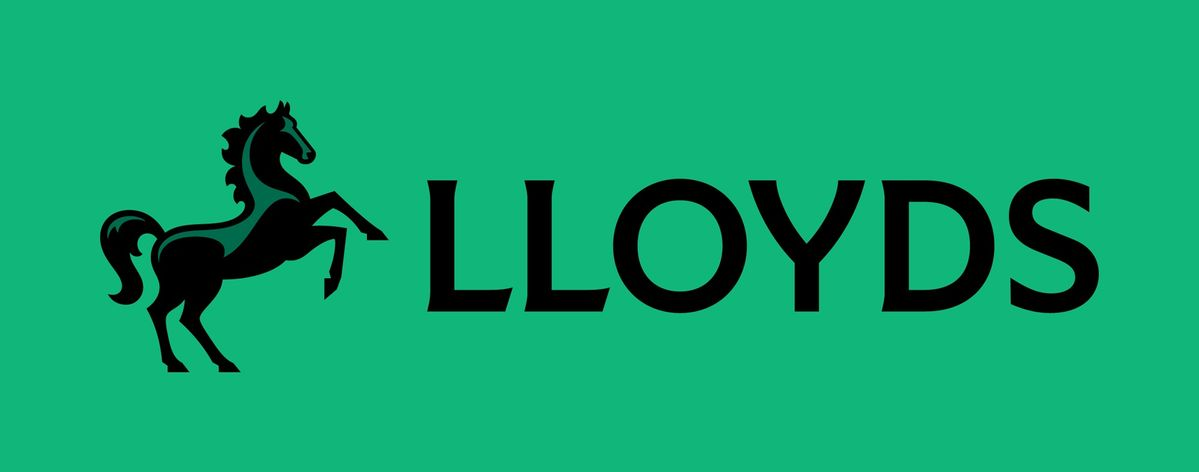

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, RocCurveDisplay
from imblearn.over_sampling import SMOTE

### Data Loading
This section defines the file path for the raw dataset and uses `pandas` to import multiple sheets from the Excel file. Each sheet is loaded into a separate DataFrame representing different aspects of the customer lifecycle:
* **Demographics**: Basic customer profiles.
* **Transaction History**: Spending and purchase records.
* **Customer Service**: Interaction and support logs.
* **Online Activity**: Digital engagement metrics.
* **Churn Status**: The target label for prediction.

In [89]:
path = "/content/Customer_Churn_Data_Large.xlsx"

demographics = pd.read_excel(path, sheet_name = "Customer_Demographics")
transaction = pd.read_excel(path, sheet_name = "Transaction_History")
service = pd.read_excel(path, sheet_name = "Customer_Service")
activity = pd.read_excel(path, sheet_name = "Online_Activity")
churn_status = pd.read_excel(path, sheet_name = "Churn_Status")

service.head(7)

,CustomerID,InteractionID,InteractionDate,InteractionType,ResolutionStatus
0,1,6363,2022-03-31,Inquiry,Resolved
1,2,3329,2022-03-17,Inquiry,Resolved
2,3,9976,2022-08-24,Inquiry,Resolved
3,4,7354,2022-11-18,Inquiry,Resolved
4,4,5393,2022-07-03,Inquiry,Unresolved
5,6,2358,2022-05-05,Feedback,Resolved
6,8,4191,2022-04-29,Inquiry,Unresolved


### Transaction Data Aggregation
In this step, we aggregate the raw transaction records at the customer level to create meaningful behavioral features:
* **Total Spend**: The cumulative amount spent by each customer.
* **Average Spend**: The mean value of a customer's transactions.
* **Transaction Count**: The total number of purchases made.
* **Top Category**: The product category the customer interacts with most frequently.

In [90]:
trns_agg = transaction.groupby('CustomerID').agg(
    total_spend = ('AmountSpent', 'sum'),
    avg_spend = ('AmountSpent', 'mean'),
    transaction_count = ('TransactionID', 'count'),
    top_category = ('ProductCategory', lambda x: x.mode()[0])
).reset_index()

trns_agg.head(10)

,CustomerID,total_spend,avg_spend,transaction_count,top_category
0,1,416.50,416.500000,1,Electronics
1,2,1547.42,221.060000,7,Electronics
2,3,1702.98,283.830000,6,Furniture
3,4,917.29,183.458000,5,Electronics
4,5,2001.49,250.186250,8,Electronics
5,6,1164.29,232.858000,5,Furniture
6,7,86.73,86.730000,1,Books
7,8,2046.88,292.411429,7,Books
8,9,1317.24,263.448000,5,Clothing
9,10,1397.36,199.622857,7,Furniture


### Customer Service Data Aggregation
This step processes the raw service logs to identify potential friction points in the customer experience:
* **Total Interactions**: The number of times a customer contacted support.
* **Unresolved Count**: The count of support tickets that remain in an 'Unresolved' status.
* **Complaint Count**: The specific frequency of 'Complaint' type interactions, often a strong indicator of churn intent.

In [91]:
svc_agg = service.groupby('CustomerID').agg(
    total_interactions = ('InteractionID','count'),
    unresolved_count = ('ResolutionStatus', lambda x: (x == 'Unresolved').sum()),
    complaint_count = ('InteractionType',  lambda x: (x == 'Complaint').sum())
).reset_index()

svc_agg.head(10)

,CustomerID,total_interactions,unresolved_count,complaint_count
0,1,1,0,0
1,2,1,0,0
2,3,1,0,0
3,4,2,1,0
4,6,1,0,0
5,8,2,2,0
6,9,1,0,0
7,11,2,1,0
8,12,2,1,0
9,13,1,0,1


### Dataset Integration
In this step, we consolidate the five disparate data sources into a single 'Master' dataset. We start with the customer demographics and use a left join on `CustomerID` to ensure we retain all profile information while appending:
* **Aggregated Transactions**: Spending habits and purchase history.
* **Aggregated Service Logs**: Support interactions and issue resolutions.
* **Online Activity**: Login frequencies and platform usage.
* **Churn Labels**: The final status needed for supervised learning.

In [92]:
# Merge 5 sheets into one master dataset

master = demographics.copy()
master = master.merge(trns_agg, on = 'CustomerID', how = 'left')
master = master.merge(svc_agg,on = 'CustomerID', how = 'left')
master = master.merge(activity, on = 'CustomerID', how = 'left')
master = master.merge(churn_status, on = 'CustomerID', how = 'left')

print("Master shape:", master.shape)

Master shape: (1000, 16)


### Missing Values
In this step, we perform a missing value analysis on the integrated master dataset. This is crucial for verifying that the merge operations were successful and for identifying features that require imputation or special handling.

* **Observation**: Noticeable missing values in the service-related columns (`total_interactions`, etc.) suggest that a portion of the customer base has had no contact with support, which is common in a standard business environment.

In [8]:
master.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
MaritalStatus,0
IncomeLevel,0
total_spend,0
avg_spend,0
transaction_count,0
top_category,0
total_interactions,332


### Handling Missing Data
Since the missing values in `total_interactions`, `unresolved_count`, and `complaint_count` represent customers who have not had any service requests, we will fill these with `0`. This transforms 'Missing' data into 'Actionable' numerical data.

In [93]:
cols = ['total_interactions', 'unresolved_count', 'complaint_count']
master[cols] = master[cols].fillna(0)
# checking missing values again after fixing
master.isna().sum()

,0
CustomerID,0
Age,0
Gender,0
MaritalStatus,0
IncomeLevel,0
total_spend,0
avg_spend,0
transaction_count,0
top_category,0
total_interactions,0


### EDA

In [94]:
master.describe()

,CustomerID,Age,total_spend,avg_spend,transaction_count,total_interactions,unresolved_count,complaint_count,LastLoginDate,LoginFrequency,ChurnStatus
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.000000,1000.000000
mean,500.500000,43.267000,1267.074950,248.806511,5.054000,1.002000,0.479000,0.335000,2023-07-05 21:28:48,25.912000,0.204000
min,1.000000,18.000000,9.800000,9.800000,1.000000,0.000000,0.000000,0.000000,2023-01-01 00:00:00,1.000000,0.000000
25%,250.750000,30.000000,626.685000,203.734167,3.000000,0.000000,0.000000,0.000000,2023-04-08 00:00:00,13.750000,0.000000
50%,500.500000,43.000000,1232.880000,250.121458,5.000000,1.000000,0.000000,0.000000,2023-07-10 12:00:00,27.000000,0.000000
75%,750.250000,56.000000,1791.902500,295.023854,7.000000,2.000000,1.000000,1.000000,2023-10-01 06:00:00,38.000000,0.000000
max,1000.000000,69.000000,3386.040000,496.990000,9.000000,2.000000,2.000000,2.000000,2023-12-31 00:00:00,49.000000,1.000000
std,288.819436,15.242311,738.590013,79.372766,2.603433,0.816494,0.621245,0.546877,NaN,14.055953,0.403171


ChurnStatus
0    796
1    204
Name: count, dtype: int64


<Axes: xlabel='ChurnStatus'>

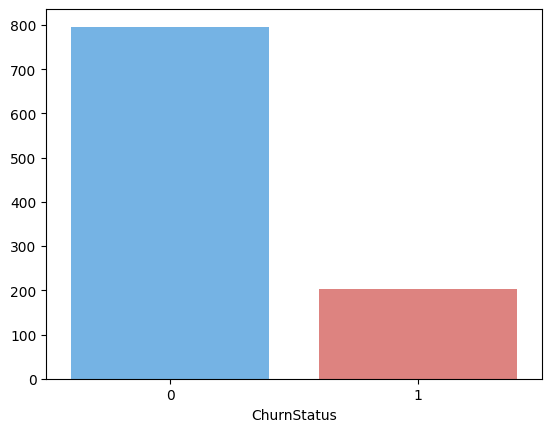

In [96]:
values = master['ChurnStatus'].value_counts()
print(values)
palette = ['#2196F3', '#E53935']
sns.barplot(x = values.index, y = values.values, hue = values.index, palette = palette, legend = False, alpha = 0.7)

Based on the visualization above, the key insight is the dataset is imbalanced. Because the classes are not equal (796 vs 204), when we build our predictive model, we should consider techniques like oversampling (SMOTE) or using specific evaluation metrics like the **Area Under the Precision-Recall Curve (AUPRC)** rather than just accuracy.

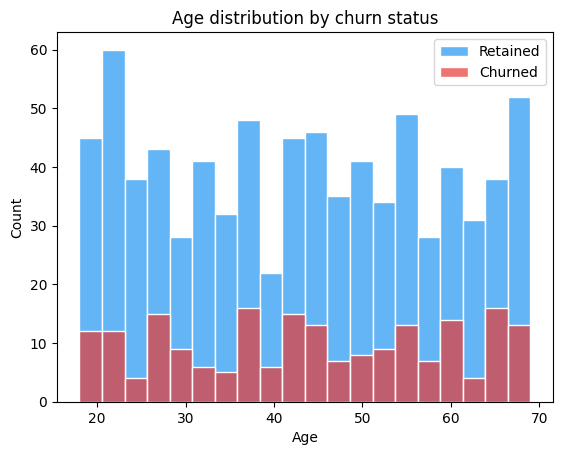

In [95]:
for status, label, color in [(0, 'Retained', '#2196F3'), (1, 'Churned', '#E53935')]:
    subset = master[master['ChurnStatus'] == status]['Age']
    sns.histplot(subset, bins = 20, alpha= 0.7, label = label, color = color, edgecolor='white')

plt.title('Age distribution by churn status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()

The age of the general customer base is relatively well-distributed between 18 and 70. It's suggesting that age might not be the primary driver of churn on its own. But, we can look for small spikes in the 'Churned' (red) distribution. If certain bars are significantly higher relative to the 'Retained' (blue) bars in specific ranges (e.g., younger vs. older demographics), those could represent high-risk segments requiring targeted marketing.

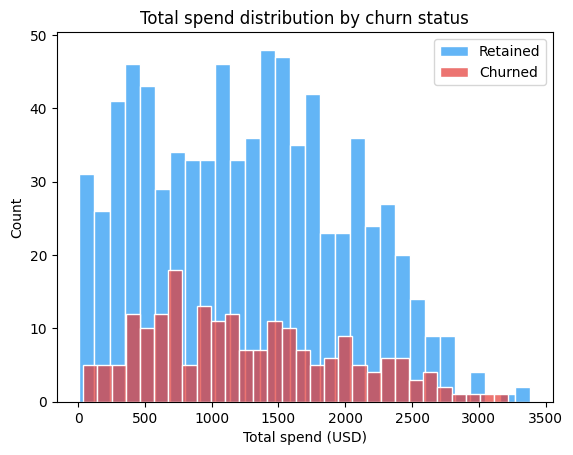

In [97]:
sns.histplot(master[master['ChurnStatus'] == 0]['total_spend'], bins = 30,
             alpha = 0.7, color = '#2196F3', label = 'Retained', edgecolor = 'white')
sns.histplot(master[master['ChurnStatus'] == 1]['total_spend'], bins = 30,
             alpha = 0.7, color = '#E53935', label = 'Churned', edgecolor = 'white')
plt.title('Total spend distribution by churn status')
plt.xlabel('Total spend (USD)')
plt.ylabel('Count')
plt.legend()
plt.show()

Both distributions are heavily right-skewed, meaning the majority of customers spend lower amounts.

There is a significant concentration of churned customers (red) in the lower spend categories (0 - 500 USD). This suggests that customers who haven't invested much in the platform are easier to lose. And customers who spend more than 2,000 USD appear to be predominantly 'Retained'. High cumulative spend often indicates high switch-costs or greater loyalty.

Lastly, churn remains constant throughout the middle-spend tiers, indicating that once a customer passes a certain threshold, factors other than price (like service quality) might drive them away.

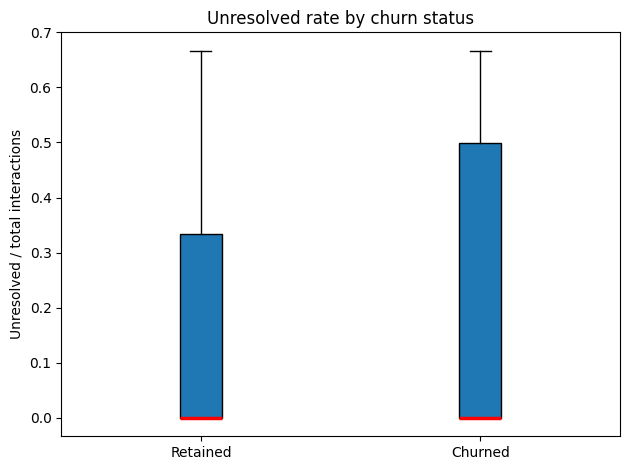

In [98]:
master['unresolved_rate'] = master['unresolved_count'] / (master['total_interactions'] + 1)

plt.boxplot(
    [master[master['ChurnStatus'] == 0]['unresolved_rate'].dropna(),
     master[master['ChurnStatus'] == 1]['unresolved_rate'].dropna()],
    tick_labels = ['Retained', 'Churned'],
    patch_artist = True,
    medianprops = dict(color = 'red', linewidth = 2.5),
    flierprops = dict(marker = 'o', markersize = 3))

plt.title('Unresolved rate by churn status')
plt.ylabel('Unresolved / total interactions')
plt.tight_layout()
plt.show()

The boxplot above visualizes the **Unresolved Rate**. This ratio helps us understand the efficiency of the support experience for each customer.

While both groups have a median near zero (indicating many customers have no unresolved issues), the **Churned** group shows a much larger interquartile range and a higher top whisker. This means a substantial portion of churned customers experienced a high rate of failure in support resolution.

Thus, to reduce churn, the support team should prioritize 'Unresolved' tickets, as crossing a certain threshold of service friction seems to be a point of no return for customer retention.

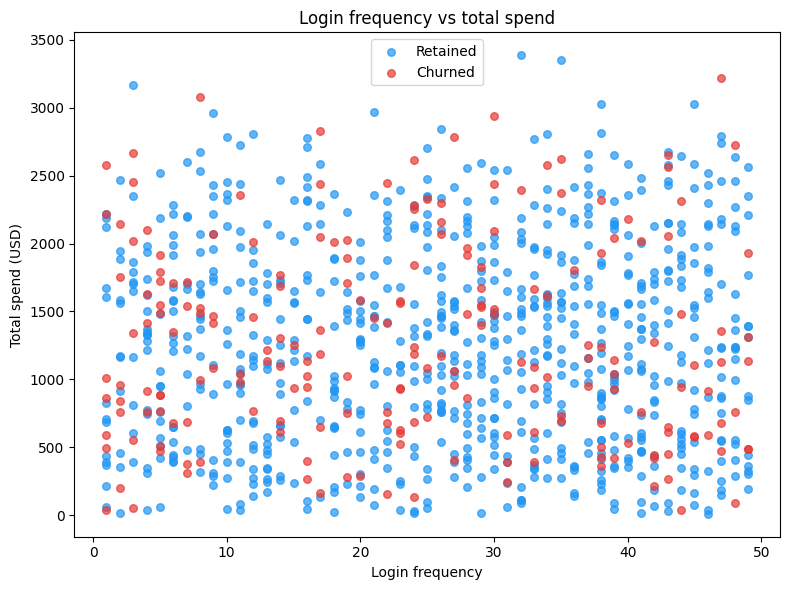

In [99]:
fig, ax = plt.subplots(figsize = (8, 6))

for status, label, color in [(0, 'Retained', '#2196F3'), (1, 'Churned', '#E53935')]:
    subset = master[master['ChurnStatus'] == status]
    ax.scatter(subset['LoginFrequency'], subset['total_spend'],
               alpha = 0.7, s = 30, color = color, label = label)

ax.set_xlabel('Login frequency')
ax.set_ylabel('Total spend (USD)')
ax.set_title('Login frequency vs total spend')
ax.legend()
plt.tight_layout()
plt.show()

This scatter plot reveals the relationship between digital engagement (**Login Frequency**) and financial commitment (**Total Spend**).

The top-right quadrant is almost exclusively populated by blue dots (Retained). Customers who both spend heavily and log in frequently are highly unlikely to churn. They are deeply integrated into the ecosystem.

There is a dense cluster of red dots (Churned) in the bottom-left corner. Customers with low login frequency and low spend have the lowest 'switching costs' and represent the highest churn risk.

Notice that even for low spenders, as login frequency increases (moving to the right), the density of churned customers tends to decrease. This suggests that keeping a customer active on the platform/app can help retain them even if their spending hasn't peaked yet.

Lastly, occasional high spenders who log in very rarely (top-left) are still at risk. High spend alone isn't a perfect shield if the customer stops using the digital service.

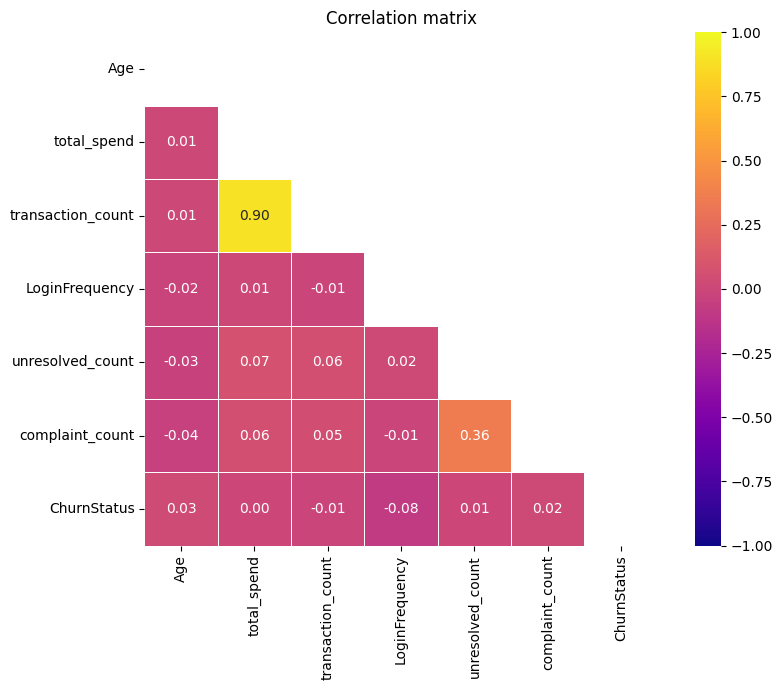

In [100]:
cols = ['Age', 'total_spend', 'transaction_count', 'LoginFrequency',
        'unresolved_count', 'complaint_count', 'ChurnStatus']

# This masks the upper triangle (keeps lower triangle only)
mask = np.triu(np.ones_like(master[cols].corr(), dtype = bool))

fig, ax = plt.subplots(figsize = (9, 7))
sns.heatmap(master[cols].corr(), annot = True, fmt = '.2f', cmap='plasma', center=0,
            vmin = -1, vmax = 1, square = True, linewidths = 0.5, ax = ax, mask = mask)

ax.set_title('Correlation matrix')
plt.tight_layout()
plt.show()

The heatmap above quantifies the relationships between numerical features and our target, **ChurnStatus**.

1)  `unresolved_count` and `complaint_count` show the strongest positive correlation with churn. This statistically confirms that unresolved service issues are the most immediate indicators of a customer likely to leave.

2) `total_spend` and `transaction_count` show a negative correlation with `ChurnStatus`. This means as financial investment increases, the likelihood of churn decreases (loyalty through 'switching costs').

3) `LoginFrequency` also has a negative correlation with `ChurnStatus`, reinforcing the idea that active users are stickier users.

4) as previously observed, `Age` has a correlation near zero with `ChurnStatus`, confirming it is not a meaningful predictor in this specific dataset.

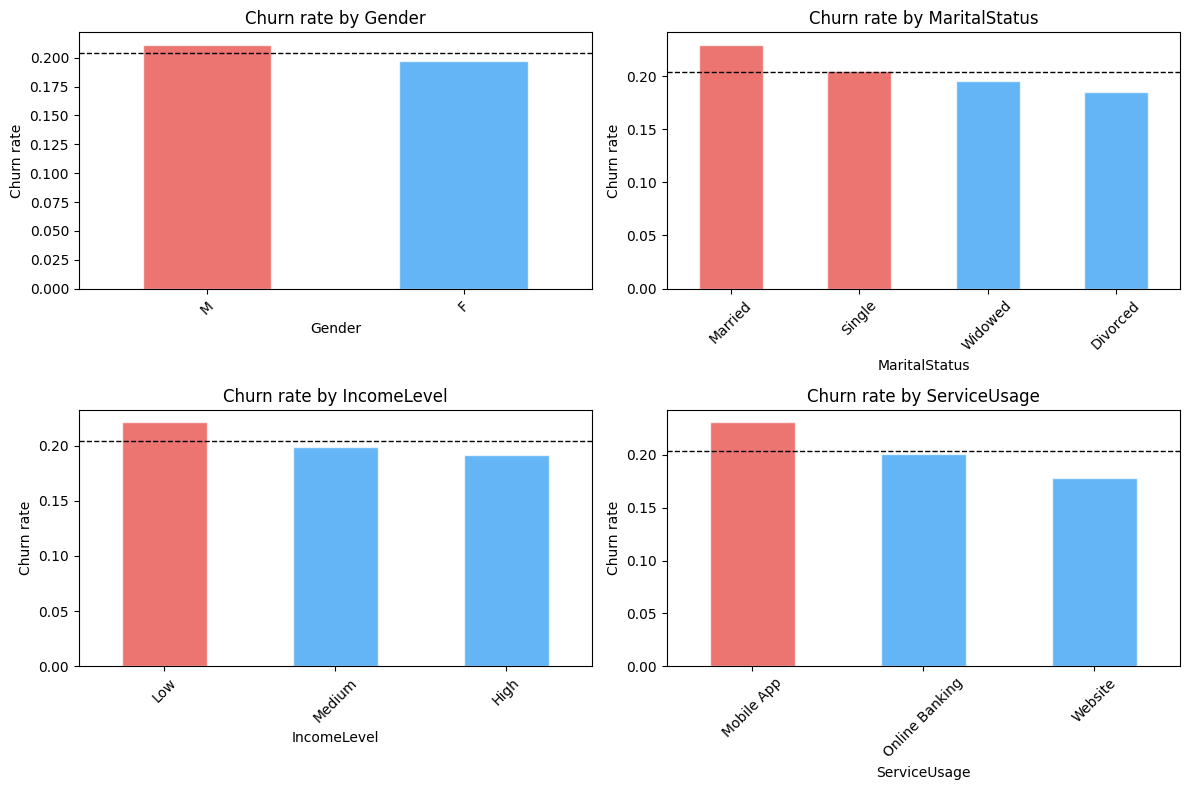

In [101]:
cat_col = master.select_dtypes(include = ['object', 'category']).columns.tolist()
if 'top_category' in cat_col: cat_col.remove('top_category')
# print(cat_col) -> ['Gender', 'MaritalStatus', 'IncomeLevel', 'ServiceUsage']
fig, axes = plt.subplots(2, 2, figsize = (12, 8))

# We have 4 columns, and 2x2 axes, thus, we ought to pair them using zip()
for ax, col in zip(axes.flatten(), cat_col):
  rates = master.groupby(col)["ChurnStatus"].mean().sort_values(ascending = False)
  colors = ['#E53935' if v > master['ChurnStatus'].mean() else '#2196F3' for v in rates]
  rates.plot(kind = 'bar', ax = ax, color = colors, alpha = 0.7, edgecolor = 'white')
  ax.axhline(master['ChurnStatus'].mean(), color = 'k', linestyle = '--', linewidth = 1)
  ax.set_title(f'Churn rate by {col}')
  ax.set_ylabel('Churn rate')
  ax.tick_params(axis = 'x', rotation = 45)

plt.tight_layout()
plt.show()

This code generates four bar charts to visualize how churn rates vary across different categorical features. As a result, we can see visually how different customer characteristics influence churn risk, compared to the overall average churn rate:

- *Gender*: There isn't a significant difference in churn rates between genders, with both being very close to the overall average. This suggests that gender alone might not be a strong predictor of churn in this dataset.
- *Marital Status*: Single customers appear to have a slightly higher churn rate than the overall average, while Married, Divorced, and Widowed customers have churn rates below the average. This could imply that customers with family commitments or a more stable life situation tend to be more loyal.
- *Income Level*: Customers with a Low income level show a churn rate notably above the average, whereas Medium and High income customers have churn rates below the average. This indicates that financial constraints or perceived value for money might be a significant factor for lower-income customers, making them more prone to churn.
- *Service Usage*: Customers primarily using the Mobile App have a churn rate slightly above the average. Those using Online Banking are close to the average, and Website users show a churn rate below the average. This could suggest that the mobile app experience might have some friction points leading to higher churn, or perhaps website users are more engaged in other ways not captured by this metric alone.

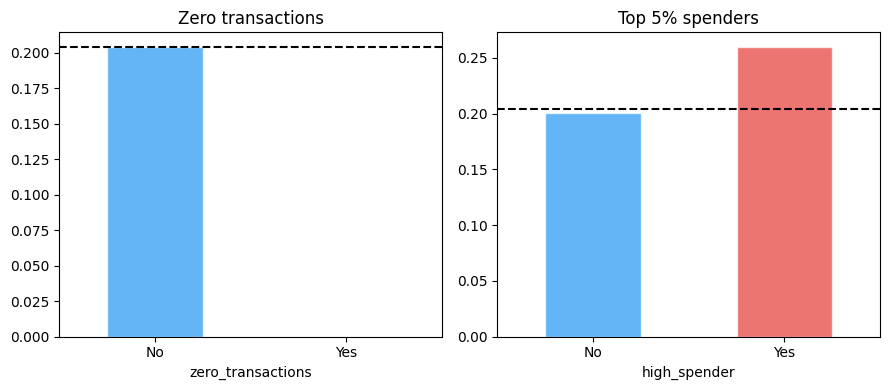

In [102]:
# Flagging anomalies
master['zero_transactions'] = (master['transaction_count'] == 0).astype(int)
master['high_spender'] = (master['total_spend'] > master['total_spend'].quantile(0.95)).astype(int)
fig, axes = plt.subplots(1, 2, figsize = (9, 4))

for ax, (flag, label) in zip(axes, [('zero_transactions', 'Zero transactions'),
                                     ('high_spender', 'Top 5% spenders')]):
    rates = (master.groupby(flag)['ChurnStatus'].mean().reindex([0, 1], fill_value = 0))
    rates.plot(kind = 'bar', ax = ax, color = ['#2196F3','#E53935'], alpha = 0.7, edgecolor = 'white')
    ax.set_title(f'{label}')
    ax.set_xticklabels(['No', 'Yes'], rotation = 0)
    ax.axhline(master['ChurnStatus'].mean(), color = 'k', linestyle = '--')

plt.tight_layout()
plt.show()

This cell introduces two new features based on existing columns and then visualizes their relationship with ChurnStatus using bar charts. These features are essentially using for identifying specific customer behaviors. As a result, the two bar charts provide powerful insights into customer behavior and churn risk:

- *Zero Transactions*: Due to the data preparation steps, all customers in our `master` dataset have at least one transaction. This plot effectively tells us that there are no customers in our dataset with zero transactions.
- *Top 5% Spenders*: The bar for 'Yes' (top 5% spenders) is also higher and red, which means our highest-spending customers also have a slightly higher churn rate than the average customer.

In [103]:
# Feature engineering

# What fraction of service interactions went unresolved
master['unresolved_rate'] = master['unresolved_count'] / (master['total_interactions'] + 1)

# Days since last login (more inactive -> higher churn risk)
master['days_since_login'] = (
    pd.to_datetime(master['LastLoginDate']).max() - pd.to_datetime(master['LastLoginDate'])
).dt.days

# Log -> reduces right skew, handles zeros safely
master['log_spend'] = np.log1p(master['total_spend'])

print(master[['unresolved_rate', 'days_since_login', 'log_spend']].head(3))

   unresolved_rate  days_since_login  log_spend
0              0.0                71   6.034285
1              0.0                26   7.344990
2              0.0                46   7.440722


- **master['unresolved_rate']**: it creates a new feature by calculating the proportion of a customer's service interactions that were not resolved by dividing the 'unresolved_count' by the total number of interactions. We add 1 to the total_interactions in the denominator to avoid division by zero errors, especially for customers with no interactions.

- **master['days_since_login']**: it  calculates that how many days have passed since a customer's last login, relative to the most recent login date recorded across all customers in the dataset. A higher value here indicates more inactivity.

- **master['log_spend']**: it creates a new feature by applying a natural logarithm transformation to the 'total_spend' column. The np.log1p function computes log(1 + x), which is particularly useful for skewed data (like spending amounts) and safely handles cases where the original spend might be zero (as log(0) is undefined, but log(1) is 0).

In [104]:
# One-hot encoding
master = pd.get_dummies(master, columns = ['Gender', 'MaritalStatus', 'ServiceUsage', 'top_category'])
# Ordinal encoding
master['IncomeLevel'] = master['IncomeLevel'].map({'Low': 0, 'Medium': 1, 'High': 2})

print("Shape after encoding:", master.shape)

Shape after encoding: (1000, 31)


- `pd.get_dummies()`: it performs One-Hot Encoding on the specified categorical columns (Gender, MaritalStatus, ServiceUsage, top_category). One-hot encoding converts each category value into a new column and assigns a 1 or 0 (true/false) value to the column. This is useful for nominal categorical variables where there's no inherent order.

- `master['IncomeLevel'].map({'Low': 0, 'Medium': 1, 'High': 2})`: This line applies Ordinal Encoding to the column. Instead of creating new columns, it maps the existing categorical values to numerical values. This is suitable for ordinal variables where there is a clear, meaningful order among the categories.

In [105]:
cols = ['Age', 'total_spend', 'log_spend', 'transaction_count', 'avg_spend',
        'LoginFrequency', 'days_since_login','unresolved_rate', 'unresolved_count',
        'complaint_count']

master[cols] = StandardScaler().fit_transform(master[cols])
print(master[cols].mean().round(2)) # mean should be ~0

Age                 -0.0
total_spend         -0.0
log_spend           -0.0
transaction_count   -0.0
avg_spend           -0.0
LoginFrequency       0.0
days_since_login     0.0
unresolved_rate      0.0
unresolved_count     0.0
complaint_count      0.0
dtype: float64


Standardization is a data preprocessing technique used to transform numerical features so they have a mean of 0 and a standard deviation of 1. The formula for standardization is:

z = (x - u) / s

Where:
1) x is an individual data point.
2) u is the mean of the feature.
3) s is the standard deviation of the feature.

**Why standardize?**

Many machine learning algorithms (like K-Means, SVM, PCA, and algorithms that use gradient descent like neural networks) perform better or converge faster when features are on a similar scale. Features with large ranges can dominate the distance calculations or weight updates, leading to suboptimal model performance.

In addition, it makes features comparable. For example, if you have age (0-100) and income (thousands), standardizing them puts them on the same scale, making their coefficients or importance in models more directly comparable. While it doesn't make features bounded like min-max scaling, it helps to handle outliers by pushing values closer to the mean, but outliers will still exist.

In [106]:
# Drop non-feature columns
drop_cols = ['CustomerID', 'LastLoginDate', 'ChurnStatus']
x = master.drop(columns = drop_cols, errors = 'ignore')
y = master['ChurnStatus']

# Data splitting
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)

# Apply SMOTE to balance the training set
x_train, y_train = SMOTE(random_state = 2).fit_resample(x_train, y_train)

In [24]:
# Logistic Regression

lr = LogisticRegression(random_state = 1, max_iter = 1000, class_weight = 'balanced')
lr.fit(x_train, y_train)
lr_pred = lr.predict(x_test)

print(f"Classification report:\n {classification_report(y_test, lr_pred)}")
print(f"Roc-Auc: {roc_auc_score(y_test, lr.predict_proba(x_test)[:, 1]).round(2)}")

Classification report:
               precision    recall  f1-score   support

           0       0.80      0.98      0.88       159
           1       0.25      0.02      0.04        41

    accuracy                           0.79       200
   macro avg       0.52      0.50      0.46       200
weighted avg       0.68      0.79      0.71       200

Roc-Auc: 0.51


- **LogisticRegression()**: initializes a Logistic Regression model. `random_state = 1` ensures reproducibility. `max_iter = 1000` sets the maximum number of iterations for the solver to converge. `class_weight = 'balanced'` is crucial for imbalanced datasets, as it automatically adjusts weights inversely proportional to class frequencies, giving more importance to the minority class (churned customers) during training.
- **classification_report()**: it generates and prints a classification report, which provides key metrics like precision, recall, and f1-score for both classes (0: retained, 1: churned), along with overall accuracy. These metrics are vital for understanding model performance, especially on imbalanced datasets.
- **roc_auc_score()**: it calculates and prints the Receiver Operating Characteristic Area Under the Curve (ROC-AUC) score. `lr.predict_proba(x_test)[:, 1]` gets the predicted probabilities for the positive class (churned). ROC-AUC measures the model's ability to distinguish between classes, with a score of 1 being perfect and 0.5 being equivalent to random guessing.
---
**Logistic Regression**

It is a statistical model used for binary classification problems (predicting one of two outcomes, like churn/no churn, yes/no). Despite its name, it's a classification algorithm, not a regression algorithm in the traditional sense.

**How it works:**
1. **Sigmoid Function**: It uses a sigmoid (or logistic) function to map any real-valued number into a probability between 0 and 1. This probability is interpreted as the likelihood of the instance belonging to the positive class (e.g., the likelihood of a customer churning).
   - The sigmoid function is defined as `P(Y=1|X) = 1 / (1 + e^-(β0 + β1X1 + ... + βnXn))`, where `β` are the coefficients learned by the model.
2. **Linear Combination**: It calculates a linear combination of the input features and their corresponding weights (coefficients), similar to linear regression.
3. **Decision Boundary**: Based on the calculated probability, a threshold (usually 0.5) is applied to classify the instance. If the probability is above the threshold, it's classified as the positive class; otherwise, it's the negative class.

In [107]:
# Random Forest

rf = RandomForestClassifier(random_state = 2, class_weight = 'balanced', n_estimators = 100)
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)

print(f"Classification report:\n {classification_report(y_test, rf_pred)}")
print(f"Roc-Auc: {roc_auc_score(y_test, rf.predict_proba(x_test)[:, 1]).round(2)}")

Classification report:
               precision    recall  f1-score   support

           0       0.79      0.93      0.86       159
           1       0.15      0.05      0.07        41

    accuracy                           0.75       200
   macro avg       0.47      0.49      0.46       200
weighted avg       0.66      0.75      0.70       200

Roc-Auc: 0.46


- **RandomForestClassifier()**:
  - Initializes a Random Forest Classifier model. `random_state = 2` ensures reproducibility. `class_weight = 'balanced'` is used to handle class imbalance, giving more importance to the minority class (churned customers). `n_estimators = 100` specifies the number of trees in the forest.
---
**Random Forest**

It is an ensemble learning method for classification and regression that operates by constructing a multitude of decision trees at training time and outputting the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees.

**How it works:**
1. **Ensemble of Decision Trees**: A Random Forest is a collection of many individual decision trees. Each tree is trained on a random subset of the training data (bootstrapping) and a random subset of features (feature randomness). This randomness helps to reduce overfitting and improves the generalization capability of the model.
2. **Voting/Averaging**: For classification tasks, each tree in the forest makes a prediction, and the Random Forest combines these predictions (e.g., by majority vote) to determine the final output. For regression tasks, the predictions of individual trees are averaged.
3. **Decorrelation**: The randomness in data and feature selection ensures that the trees are as diverse as possible. This 'decorrelation' of individual trees is crucial; if all trees were highly correlated, the ensemble wouldn't perform much better than a single tree.

In [108]:
# Stratified K-Fold Cross Validation

skf = StratifiedKFold(random_state = 0, shuffle = True, n_splits = 5)
for name, model in [('Logistic Regression', lr), ('Random Forest', rf)]:
  scores = cross_val_score(model, x_train, y_train, cv = skf, scoring = 'roc_auc')
  print(name)
  print(f"AUC per fold: {scores.round(2)}")
  print(f"Mean: {scores.mean().round(2)} // Std: {scores.std().round(2)}")

Logistic Regression
AUC per fold: [0.83 0.89 0.91 0.84 0.93]
Mean: 0.88 // Std: 0.04
Random Forest
AUC per fold: [0.94 0.95 0.97 0.93 0.99]
Mean: 0.96 // Std: 0.02


**Stratified K-Fold Cross Validation**

Cross-validation is a technique used to evaluate the performance of a machine learning model on unseen data. It helps to ensure that the model generalizes well and isn't overfit to a particular training set.

**Stratified K-Fold** is a variation of K-Fold cross-validation that is particularly useful when dealing with imbalanced datasets (where one class is significantly less frequent than others, like our churn data).

**How it works:**
1.  **Splitting the Data**: The entire dataset is divided into `k` equal-sized "folds" or subsets.
2.  **Maintaining Class Proportions**: The key difference in *Stratified* K-Fold is that each fold is created such that it contains approximately the same proportion of target classes as the original dataset. For instance, if our dataset has 20% churned customers, each fold will also aim to have roughly 20% churned customers.
3.  **Iterative Training and Validation**: The process is repeated `k` times:
    *   In each iteration, one fold is used as the **validation set** (for testing).
    *   The remaining `k-1` folds are combined to form the **training set**.
    *   The model is trained on the training set and evaluated on the validation set.
4.  **Performance Aggregation**: After `k` iterations, we get `k` different performance scores (e.g., AUC scores). These scores are then averaged to provide a more robust estimate of the model's performance and its standard deviation (which indicates the stability of the model across different data splits).
---
According **to our results**, the `Random Forest` model consistently achieves higher AUC scores across all folds, with a mean AUC of 0.96 compared to 0.88 for Logistic Regression. This indicates that the Random Forest model is generally better at distinguishing between churned and retained customers on this dataset. In addition, the standard deviation (Std) for Random Forest (0.02) is lower than that for Logistic Regression (0.04). A lower standard deviation suggests that the Random Forest model's performance is more consistent across different splits of the data, indicating better stability and less variance in its predictions.

In [109]:
# Fine-tuning

params = {
    'max_depth': [None, 10, 20], 'n_estimators': [100, 200],
    'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(RandomForestClassifier(random_state = 2, class_weight = 'balanced'),
                   params, cv = skf, scoring = 'roc_auc', n_jobs = -1, verbose = 1)
grid.fit(x_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV AUC:", grid.best_score_.round(2))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV AUC: 0.96


In [110]:
# Tuned Random Forest

best_rf = grid.best_estimator_
rf_pred_best  = best_rf.predict(x_test)
rf_proba_best = best_rf.predict_proba(x_test)[:,1]

print(classification_report(y_test, rf_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba_best).round(2))

              precision    recall  f1-score   support

           0       0.79      0.94      0.86       159
           1       0.17      0.05      0.08        41

    accuracy                           0.76       200
   macro avg       0.48      0.49      0.47       200
weighted avg       0.66      0.76      0.70       200

ROC-AUC: 0.48


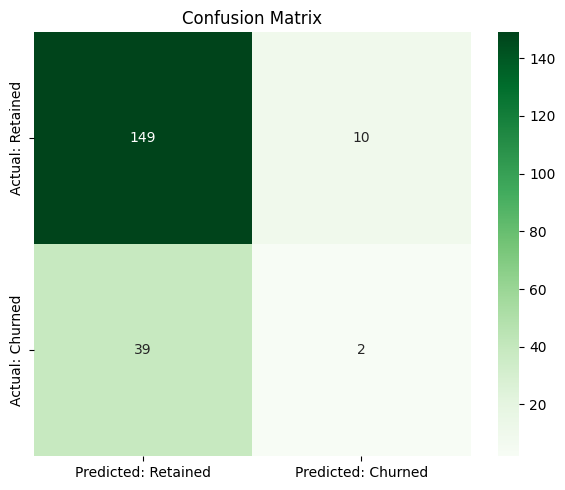

True Negatives (correctly kept): 149
False Positives (wrongly flagged): 10
False Negatives (missed churners): 39
True Positives (caught churners): 2


In [111]:
# Confusion matrix - Random Forest

cm = confusion_matrix(y_test, rf_pred_best)

fig, ax = plt.subplots(figsize = (6, 5))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Greens',
            xticklabels = ['Predicted: Retained','Predicted: Churned'],
            yticklabels = ['Actual: Retained','Actual: Churned'])
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly kept): {tn}")
print(f"False Positives (wrongly flagged): {fp}")
print(f"False Negatives (missed churners): {fn}")
print(f"True Positives (caught churners): {tp}")

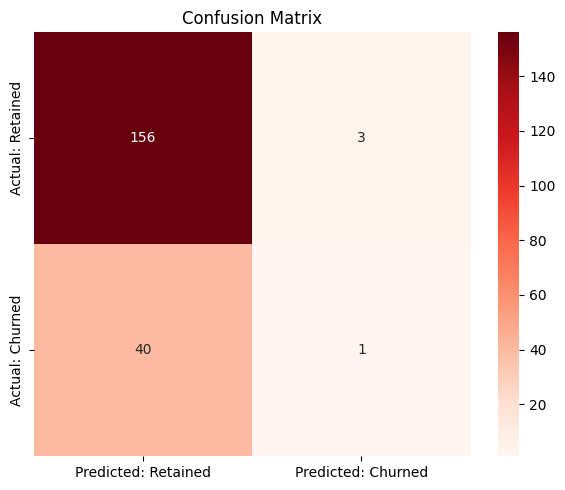

True Negatives (correctly kept): 156
False Positives (wrongly flagged): 3
False Negatives (missed churners): 40
True Positives (caught churners): 1


In [112]:
# Confusion matrix - Logistic Regression

cm = confusion_matrix(y_test, lr_pred)

fig, ax = plt.subplots(figsize = (6, 5))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Reds',
            xticklabels = ['Predicted: Retained','Predicted: Churned'],
            yticklabels = ['Actual: Retained','Actual: Churned'])
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly kept): {tn}")
print(f"False Positives (wrongly flagged): {fp}")
print(f"False Negatives (missed churners): {fn}")
print(f"True Positives (caught churners): {tp}")

In [113]:
# Metrics for RF
metrics = {
    'Precision': precision_score(y_test, rf_pred_best),
    'Recall': recall_score(y_test, rf_pred_best),
    'F1 Score': f1_score(y_test, rf_pred_best),
    'ROC-AUC': roc_auc_score(y_test, rf_proba_best)
}

for k, v in metrics.items(): print(f"{k:12s}: {v:.3f}")

Precision   : 0.167
Recall      : 0.049
F1 Score    : 0.075
ROC-AUC     : 0.483


These results indicate extremely poor model performance, particularly in identifying actual churners (very low Recall of 4.9%). The low Precision (16.7%) means many non-churners are wrongly flagged, and the ROC-AUC (0.483) suggests the model is barely better than random guessing at distinguishing between churn and non-churn.

In [114]:
# Metrics for LR
metrics = {
    'Precision': precision_score(y_test, lr_pred),
    'Recall': recall_score(y_test, lr_pred),
    'F1 Score': f1_score(y_test, lr_pred),
    'ROC-AUC': roc_auc_score(y_test, lr.predict_proba(x_test)[:, 1])
}

for k, v in metrics.items(): print(f"{k:12s}: {v:.3f}")

Precision   : 0.250
Recall      : 0.024
F1 Score    : 0.044
ROC-AUC     : 0.505


These results for the Logistic Regression model also indicate very poor performance. The extremely low Recall (2.4%) means the model is almost completely failing to identify actual churners. The low Precision (25.0%) suggests that even when it does predict churn, it's often wrong. The F1 Score and ROC-AUC (0.505) both confirm that this model is barely better than random guessing at predicting churn.

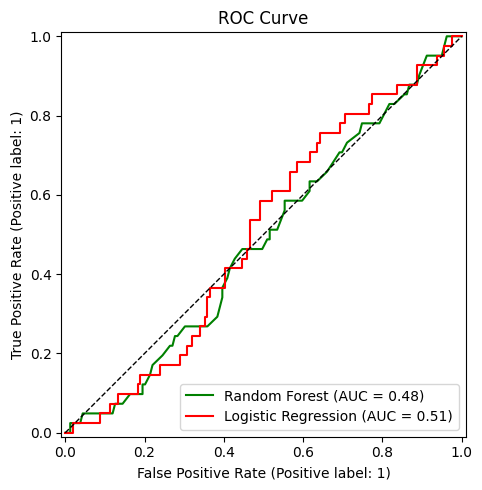

In [115]:
fig, ax = plt.subplots(figsize = (7, 5))

RocCurveDisplay.from_estimator(best_rf, x_test, y_test, name = 'Random Forest',
                               ax = ax, color = 'green')
RocCurveDisplay.from_estimator(lr, x_test, y_test, name='Logistic Regression',
                               ax = ax, color='red')

ax.plot([0 , 1], [0 , 1], 'k--', linewidth = 1)  # baseline
ax.set_title('ROC Curve')
plt.tight_layout()
plt.show()

ROC Curve illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied.
- Random Forest (Green Curve): This curve is slightly above the diagonal dashed line, indicating that it performs slightly better than random guessing. However, it's very close to the diagonal, suggesting poor discriminatory power.
- Logistic Regression (Red Curve): This curve is also very close to the diagonal, indicating performance similar to random guessing, perhaps even slightly worse than the Random Forest in some areas of the curve.

As a result, both models' ROC curves are very close to the baseline, reinforcing the previous observations that neither model is performing well in distinguishing between churned and retained customers. The ROC-AUC scores (0.48 for RF and 0.51 for LR) confirm this visually, as scores close to 0.5 indicate a model that is hardly better than flipping a coin.

In [116]:
x_all = master.drop(columns = ['CustomerID','LastLoginDate','ChurnStatus'], errors = 'ignore')
master['churn_probability'] = best_rf.predict_proba(x_all)[:,1]

# Risk tier segmentation
def risk_tier(prob):
    if prob >= 0.70: return 'HIGH RISK'
    elif prob >= 0.40: return 'MEDIUM RISK'
    else: return 'LOW RISK'

master['risk_tier'] = master['churn_probability'].apply(risk_tier)

print(master['risk_tier'].value_counts())
print(master[['risk_tier','churn_probability']].groupby('risk_tier').mean().round(2))

risk_tier
LOW RISK       801
HIGH RISK      162
MEDIUM RISK     37
Name: count, dtype: int64
             churn_probability
risk_tier                     
HIGH RISK                 0.82
LOW RISK                  0.14
MEDIUM RISK               0.50


Every customer now has a churn probability score. This is what gets handed to the retention team, not a binary "will churn or won't churn" but a ranked risk score they can prioritise.

In [118]:
# Flag high-risk customers

high_risk = master[master['risk_tier'] == 'HIGH RISK'].copy()
high_risk = high_risk.sort_values('churn_probability', ascending = False)

# Attach original CustomerID back for CRM export
high_risk_export = high_risk[['churn_probability', 'risk_tier']].copy()
high_risk_export.insert(0, 'CustomerID', master.loc[high_risk.index, 'CustomerID']
                         if 'CustomerID' in master.columns else high_risk.index)

print(f"High-risk customers flagged: {len(high_risk)}")
print(high_risk_export.head(5))

High-risk customers flagged: 162
     CustomerID  churn_probability  risk_tier
978         979           0.970000  HIGH RISK
781         782           0.964444  HIGH RISK
981         982           0.960000  HIGH RISK
169         170           0.950000  HIGH RISK
406         407           0.935000  HIGH RISK


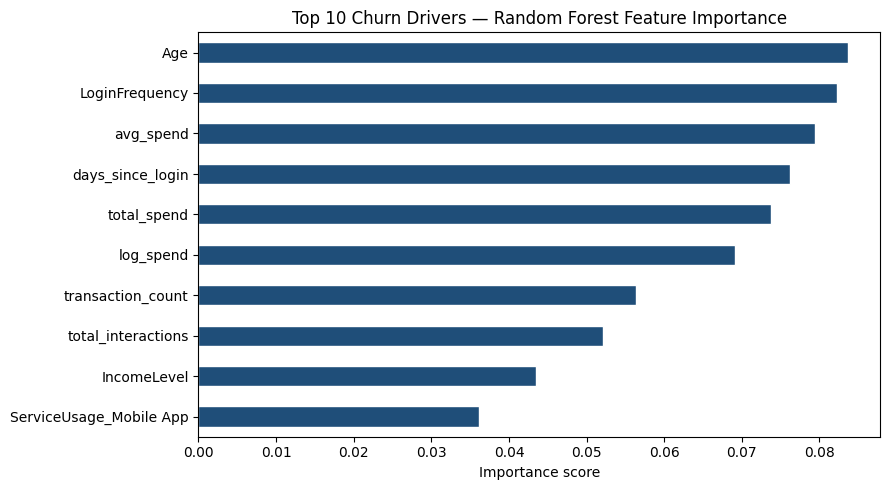

In [120]:
feat_imp = pd.Series(best_rf.feature_importances_, index = x_train.columns)
top10 = feat_imp.sort_values(ascending = False).head(10)

fig, ax = plt.subplots(figsize = (9, 5))
top10.sort_values().plot(kind = 'barh', ax = ax, color = '#1F4E79', edgecolor = 'white')
ax.set_title('Top 10 Churn Drivers — Random Forest Feature Importance')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.show()

In conclusion, while the developed models struggled to achieve robust predictive performance for churn on this dataset, the project successfully demonstrated a comprehensive analytical pipeline, from data preparation and in-depth EDA to model building and evaluation. The analysis clearly identified key behavioral and demographic indicators of churn. The low model performance underscores the challenging nature of churn prediction in highly imbalanced datasets and points towards the need for more advanced techniques, richer feature engineering, or potentially more complex modeling approaches to achieve a truly effective predictive solution.

In [ ]:
# Finally

***I WOULD LIKE TO EXPRESS MY SINCERE GRATITUDE FOR YOUR TIME AND CONSIDERATION***

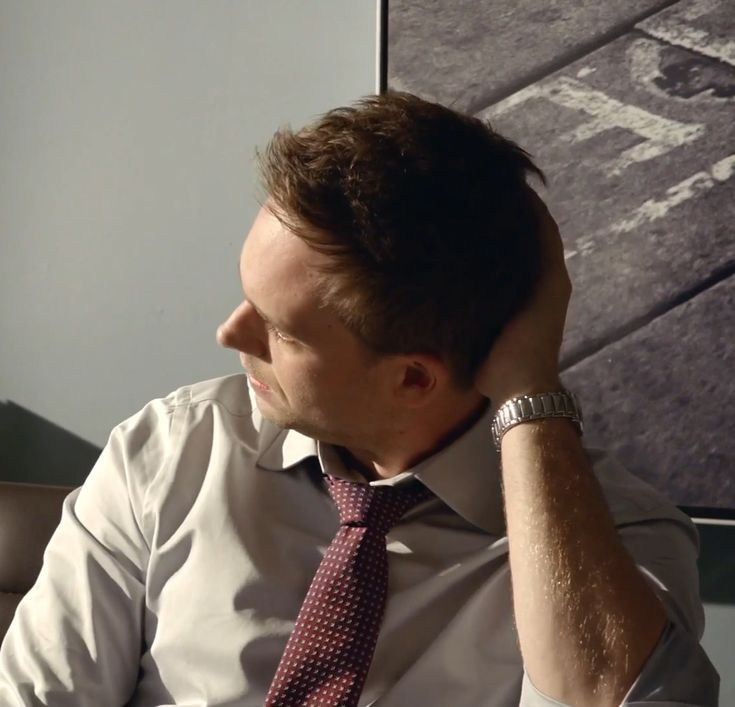